
#**Анализ факторов, влияющих на смысловую изменчивость законопроектов**

Этот файл содержит полный процесс анализа данных о законопроектах, включающий предобработку данных, построение регрессионной модели ??? и визуализацию результатов.

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import pandas as pd
import re
from scipy.stats import pearsonr, spearmanr
from scipy.stats import gaussian_kde
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

###**Предобработка данных**

Откроем файл с данными, которые получились после парсинга, NLP-анализа текста и построяния косинусной близости:

In [157]:
data = pd.read_excel('final_result_enriched.xlsx')
data.head(2)

,bill_url,Инициатор,Профильный комитет,Дата внесения в ГД,Тематический блок / Отрасль законодательства,Статус,bill_id,input_doc_url,output_doc_url,text_a,text_b,score
0,https://sozd.duma.gov.ru/bill/1060950-7,"Депутаты Государственной Думы В.И.Пискарев, А....",Комитет Государственной Думы по государственно...,23.11.2020,Государственное строительство и конституционны...,принят,1060950-7,https://sozd.duma.gov.ru/download/4060a9be-554...,https://sozd.duma.gov.ru/download/ef4d51bf-0eb...,Вносится депутатами Государственной Думы В.И.П...,Проект № 1060950-7 в третьем чтении ФЕДЕРАЛЬНЫ...,0.526161
1,https://sozd.duma.gov.ru/bill/989758-7,"Депутаты Государственной Думы А.Е.Хинштейн, С....",Комитет Государственной Думы по государственно...,16.07.2020,Государственное строительство и конституционны...,принят,989758-7,https://sozd.duma.gov.ru/download/e25cc0fd-720...,https://sozd.duma.gov.ru/download/4d0cb173-0cc...,Вносится депутатами Государственной Думы А.Е. ...,Проект № 989758-7 в третьем чтении ФЕДЕРАЛЬНЫЙ...,0.522279


In [158]:
data.columns

Index(['bill_url', 'Инициатор', 'Профильный комитет', 'Дата внесения в ГД',
       'Тематический блок / Отрасль законодательства', 'Статус', 'bill_id',
       'input_doc_url', 'output_doc_url', 'text_a', 'text_b', 'score'],
      dtype='object')

In [159]:
data.shape

(5069, 12)


Полученные данные содержат столбцы, которые не будут использоваться в модели. Удалим их, оставив только те переменные, которые необходимы для дальнейшего анализа:

In [160]:
columns_to_drop = [
    'bill_url',
    'Тематический блок / Отрасль законодательства',
    'Статус',
    'bill_id',
    'input_doc_url',
    'output_doc_url',
    'text_b'
]

data = data.drop(columns=columns_to_drop)

In [161]:
data.head(2)

,Инициатор,Профильный комитет,Дата внесения в ГД,text_a,score
0,"Депутаты Государственной Думы В.И.Пискарев, А....",Комитет Государственной Думы по государственно...,23.11.2020,Вносится депутатами Государственной Думы В.И.П...,0.526161
1,"Депутаты Государственной Думы А.Е.Хинштейн, С....",Комитет Государственной Думы по государственно...,16.07.2020,Вносится депутатами Государственной Думы А.Е. ...,0.522279



Стандартизируем инициаторов: объединяем схожие формулировки (например, "депутаты Госдумы" и "депутат Госдумы") и кодируем их в числовой формат для дальнейшего анализа.

In [162]:
actor_normalization = {
    'депутаты государственной думы': 'state_duma',
    'депутат государственной думы': 'state_duma',
    'члены совета федерации': 'federation_council',
    'член совета федерации': 'federation_council',
    'правительство российской федерации': 'government',
    'президент российской федерации': 'president',
    'суд российской федерации': 'court',

    'региональный парламент': 'regional_parliament',
    'законодательное собрание': 'regional_parliament',
    'областная дума': 'regional_parliament',
    'губернская дума': 'regional_parliament',
    'государственное собрание': 'regional_parliament',
    'народное собрание': 'regional_parliament',
    'государственный совет': 'regional_parliament',
    'верховный хурал': 'regional_parliament',
}

label_map = {
    'state_duma': 'State_duma',
    'federation_council': 'Federation_council',
    'government': 'Government',
    'president': 'President',
    'court': 'Court',
    'regional_parliament': 'Regional_parliament',
}

order = [
    'state_duma',
    'federation_council',
    'government',
    'president',
    'court',
    'regional_parliament',
]


patterns = [

    (re.compile(r'\bдепутат(ы)?\s+государственной\s+дум(ы|а)\b', re.I), 'state_duma'),

    (re.compile(r'\bчлен(ы)?\s+совета\s+федераци[ияи]\b', re.I), 'federation_council'),
    (re.compile(r'\bсенатор(ы)?\s+российской\s+федераци[ияи]\b', re.I), 'federation_council'),
    (re.compile(r'\bсовет\s+федераци[ияи]\b', re.I), 'federation_council'),

    (re.compile(r'\bправительство\s+российской\s+федераци[ияи]\b', re.I), 'government'),
    (re.compile(r'\bпрезидент\s+российской\s+федераци[ияи]\b', re.I), 'president'),

    (re.compile(r'\b(конституционный|верховный|высший\s+арбитражный|арбитражный)\s+суд\b', re.I), 'court'),

    (re.compile(r'\bзаконодательн\w*\s+собрани\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bобластн\w*\s+собрани\w*\s+депутат\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bсобрани\w*\s+депутат\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bсовет\s+народн\w*\s+депутат\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bверховн\w*\s+совет\b', re.I), 'regional_parliament'),
    (re.compile(r'\b(народн\w*\s+)?хурал\b', re.I), 'regional_parliament'),
    (re.compile(r'\bгосударственн\w*\s+совет\b', re.I), 'regional_parliament'),
    (re.compile(r'\bгосударственн\w*\s+собрани\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bнародн\w*\s+собрани\w*\b', re.I), 'regional_parliament'),

    (re.compile(r'\bобластн\w*\s+дум\w*\b', re.I), 'regional_parliament'),
    (re.compile(r'\bгубернск\w*\s+дум\w*\b', re.I), 'regional_parliament'),
    (re.compile(
        r'\bдум\w*\s+'
        r'(?:республик\w+|кра[яй]\w*|област\w+|округ\w+|автономн\w+|'
        r'города|г\.)\b',
        re.I
    ), 'regional_parliament'),

    (re.compile(
        r'\bпарламент\s+'
        r'(?:республик\w+|кра[яй]\w*|област\w+|округ\w+|автономн\w+)\b',
        re.I
    ), 'regional_parliament'),
]

def normalize_initiator_type(text: str):
    if not isinstance(text, str) or not text.strip():
        return None

    t = text.lower()
    t = re.sub(r'[^\w\s\-]', ' ', t, flags=re.U)
    t = re.sub(r'\s+', ' ', t).strip()

    found = set()

    for rx, code in patterns:
        if rx.search(t):
            found.add(code)

    for key, code in actor_normalization.items():
        if key in t:
            found.add(code)

    if not found:
        return None

    ordered = [label_map[c] for c in order if c in found]
    return ', '.join(ordered) if ordered else None

data['Initiator_type'] = data['Инициатор'].apply(normalize_initiator_type)

In [163]:
type_col = "Initiator_type"

df = data.copy()

actors = [
    "State_duma",
    "Federation_council",
    "Government",
    "President",
    "Court",
    "Regional_parliament"
]

for a in actors:
    df[f"actor_{a.lower()}"] = (
        df[type_col]
        .fillna("")
        .str.contains(rf"\b{a}\b", regex=True)
        .astype(int)
    )

data = df

Стандартизируем профильные комитеты: объединяем различные формулировки и исторические наименования комитетов, а также случаи совместного рассмотрения законопроекта несколькими комитетами, в укрупнённые тематические блоки (например, «бюджет и налоги» и «финансовый рынок», в группу финансовой политики). Это позволяет сократить избыточную категориальную вариативность и сформировать содержательно осмысленные агрегированные группы для последующего количественного анализа.

In [164]:
import pandas as pd
import re

committee_col = 'Профильный комитет'

def classify_committee(text):
    if not isinstance(text, str):
        return []

    t = text.lower()

    groups = set()

    # LAW & STATE
    if any(k in t for k in [
        'государственному строительству',
        'конституционному законодательству',
        'гражданскому, уголовному',
        'процессуальному законодательству',
        'федеративному устройству',
        'регламент',
        'контрол',
        'гражданского общества',
        'национальност'
    ]):
        groups.add('LAW_STATE')

    # FINANCE
    if any(k in t for k in ['бюджет', 'налог', 'финансов']):
        groups.add('FINANCE')

    # ECONOMY
    if any(k in t for k in [
        'экономической политике',
        'промышленности',
        'предпринимательств',
        'инновационному',
        'собственност'
    ]):
        groups.add('ECONOMY')

    # SOCIAL
    if any(k in t for k in [
        'труду',
        'социальной политике',
        'ветеран',
        'семьи, женщин'
    ]):
        groups.add('SOCIAL')

    # HEALTH
    if 'охране здоровья' in t:
        groups.add('HEALTH')

    # EDUCATION
    if any(k in t for k in [
        'образован',
        'наук',
        'культур'
    ]):
        groups.add('EDUCATION')

    # SECURITY
    if any(k in t for k in [
        'обороне',
        'безопасности',
        'противодействию коррупции'
    ]):
        groups.add('SECURITY')

    # FOREIGN
    if any(k in t for k in [
        'международ',
        'содружеств',
        'евразий'
    ]):
        groups.add('FOREIGN')

    # REGIONAL
    if any(k in t for k in [
        'региональной политике',
        'севера и дальнего востока'
    ]):
        groups.add('REGIONAL')

    # ECOLOGY
    if any(k in t for k in [
        'природн',
        'эколог'
    ]):
        groups.add('ECOLOGY')

    # INFRA
    if any(k in t for k in [
        'транспорт',
        'строительств',
        'жилищ',
        'жкх',
        'земельн'
    ]):
        groups.add('INFRA')

    # ENERGY + AGRO
    if any(k in t for k in [
        'энергетик',
        'аграр'
    ]):
        groups.add('ENERGY_AGRO')

    if not groups:
        groups.add('OTHER')

    return list(groups)


data['committee_groups'] = data[committee_col].apply(classify_committee)

In [165]:
mlb = MultiLabelBinarizer()

committee_binary = mlb.fit_transform(data['committee_groups'])

committee_df = pd.DataFrame(
    committee_binary,
    columns=[f"committee_{c.lower()}" for c in mlb.classes_]
)

data = pd.concat([data.reset_index(drop=True),
                  committee_df.reset_index(drop=True)], axis=1)

Добавим переменную длины текста

In [166]:
data["score"] = pd.to_numeric(data["score"], errors="coerce")
data = data.dropna(subset=["score", "text_a"])

data["text_length_words"] = (
    data["text_a"]
    .astype(str)
    .str.split()
    .apply(len)
)

In [167]:
data = data[data["text_length_words"] > 0]

data["log_text_length_words"] = np.log(data["text_length_words"])

Добавим переменную года внесения законопроекта

In [168]:
data["Дата внесения в ГД"] = pd.to_datetime(
    data["Дата внесения в ГД"],
    format="%d.%m.%Y",
    errors="coerce"
)

data = data.dropna(subset=["Дата внесения в ГД", "score"])

data["depth"] = 1 - pd.to_numeric(data["score"], errors="coerce")

data["year"] = data["Дата внесения в ГД"].dt.year

In [169]:
columns_to_drop = [
    'text_a',
     'Инициатор',
    'Профильный комитет',
    'Дата внесения в ГД',
     'Initiator_type',
    'committee_groups'

]

data = data.drop(columns=columns_to_drop)

In [152]:
data.head()

,score,actor_state_duma,actor_federation_council,actor_government,actor_president,actor_court,actor_regional_parliament,committee_ecology,committee_economy,committee_education,...,committee_infra,committee_law_state,committee_other,committee_regional,committee_security,committee_social,text_length_words,log_text_length_words,depth,year
0,0.526161,1,1,0,0,0,0,0,0,0,...,1,1,0,0,0,0,1324,7.188413,0.473839,2020
1,0.522279,1,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,882,6.782192,0.477721,2020
2,0.514445,1,1,0,0,0,0,0,0,0,...,1,1,0,0,0,0,145,4.976734,0.485555,2018
3,0.495059,0,0,1,0,0,0,0,0,0,...,1,1,0,0,0,0,1621,7.390799,0.504941,2017
4,0.480315,0,1,0,0,0,0,0,0,0,...,1,1,0,0,0,0,4130,8.326033,0.519685,2017


###**EDA**

Посмотрим на базовое распределение статистки:

,N,Mean,Std,Min,P01,P05,P10,Median,P90,P95,P99,Max,Skew,Kurtosis(excess),Share==0,Share==1,Any<0
score,4845,0.0639,0.064,0.0000,0.0025,0.0070,0.0108,0.0433,0.1456,0.1908,0.3089,0.5262,2.305,7.4986,0.0017,0.0000,False
depth=1-score,4845,0.9361,0.064,0.4738,0.6911,0.8092,0.8544,0.9567,0.9892,0.9930,0.9975,1.0000,-2.305,7.4986,0.0000,0.0017,False


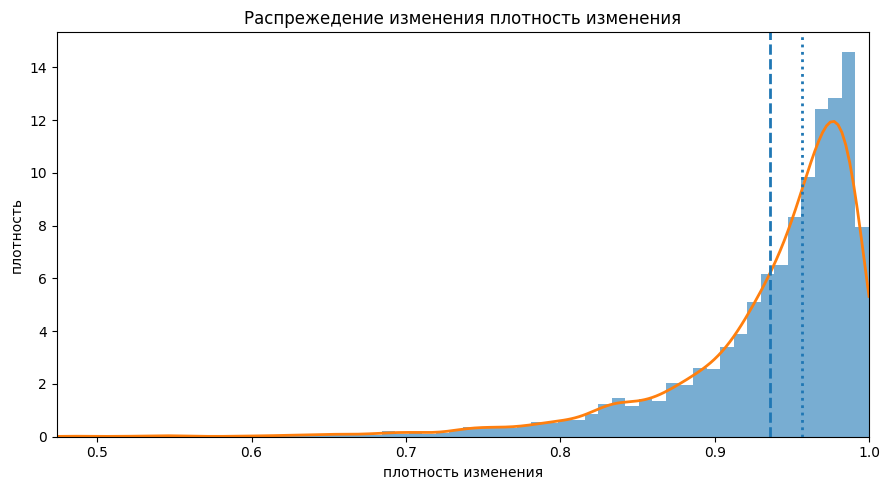

<Figure size 640x480 with 0 Axes>

In [ ]:
score_col = "score"

score = pd.to_numeric(data[score_col], errors="coerce").dropna()
depth = 1 - score

def stats_row(x: pd.Series) -> dict:
    x = x.astype(float)
    return {
        "N": int(x.shape[0]),
        "Mean": float(x.mean()),
        "Std": float(x.std(ddof=1)),
        "Min": float(x.min()),
        "P01": float(x.quantile(0.01)),
        "P05": float(x.quantile(0.05)),
        "P10": float(x.quantile(0.10)),
        "Median": float(x.median()),
        "P90": float(x.quantile(0.90)),
        "P95": float(x.quantile(0.95)),
        "P99": float(x.quantile(0.99)),
        "Max": float(x.max()),
        "Skew": float(skew(x)),
        "Kurtosis(excess)": float(kurtosis(x, fisher=True)),
        "Share==0": float((x == 0).mean()),
        "Share==1": float((x == 1).mean()),
        "Any<0": bool((x < 0).any()),
    }

stats_df = pd.DataFrame(
    [stats_row(score), stats_row(depth)],
    index=["score", "depth=1-score"]
).round(4)

display(stats_df)

depth = 1 - score

plt.figure(figsize=(9,5))

plt.hist(depth, bins=60, density=True, alpha=0.6)

xs = np.linspace(0, 1, 400)
kde = gaussian_kde(depth)
plt.plot(xs, kde(xs), linewidth=2)

plt.axvline(depth.mean(), linestyle="--", linewidth=2)
plt.axvline(depth.median(), linestyle=":", linewidth=2)

plt.xlim(depth.min(), depth.max())
plt.xlabel("плотность изменения")
plt.ylabel("плотность")
plt.title("Распрежедение изменения плотность изменения")
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

Проанализируем распределение законопроектов по типам инициаторов и оценим их численность, а также сопоставим средние и распределительные характеристики показателя score в разрезе каждой группы, чтобы выявить возможные систематические различия в степени переработки законопроектов в зависимости от институционального источника инициативы.

In [ ]:
score_col = 'score'
type_col = 'Initiator_type'

df = data.copy()

df[score_col] = pd.to_numeric(df[score_col], errors='coerce')

if date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')
    df['year'] = df[date_col].dt.year


print("\n=== Initiator_type: top combinations ===")
print(df[type_col].value_counts(dropna=False).head(30))

min_n = 50
grp = (
    df.dropna(subset=[score_col, type_col])
      .groupby(type_col)[score_col]
      .agg(n='count', mean='mean', median='median', std='std',
           p10=lambda s: s.quantile(0.10),
           p90=lambda s: s.quantile(0.90))
      .sort_values('n', ascending=False)
)


=== Initiator_type: top combinations ===
Initiator_type
Government                                             2758
State_duma                                             1031
State_duma, Federation_council                          463
President                                               346
Regional_parliament                                     253
Federation_council                                       95
Court                                                    65
None                                                     36
State_duma, Regional_parliament                          14
State_duma, Federation_council, Regional_parliament       8
Name: count, dtype: int64



=== Score by Initiator_type (combinations) ===
                                                       n      mean    median  \
Initiator_type                                                                 
Government                                          2640  0.051581  0.032492   
State_duma                                           994  0.085643  0.068007   
State_duma, Federation_council                       428  0.085715  0.066282   
President                                            330  0.054435  0.037965   
Regional_parliament                                  246  0.077480  0.058877   
Federation_council                                    90  0.088405  0.070390   
Court                                                 63  0.048938  0.040768   
State_duma, Regional_parliament                       14  0.093877  0.073587   
State_duma, Federation_council, Regional_parlia...     7  0.080411  0.072152   

                                                         std       p10 

/tmp/ipython-input-827/950496585.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=top_groups, vert=True, showfliers=False)


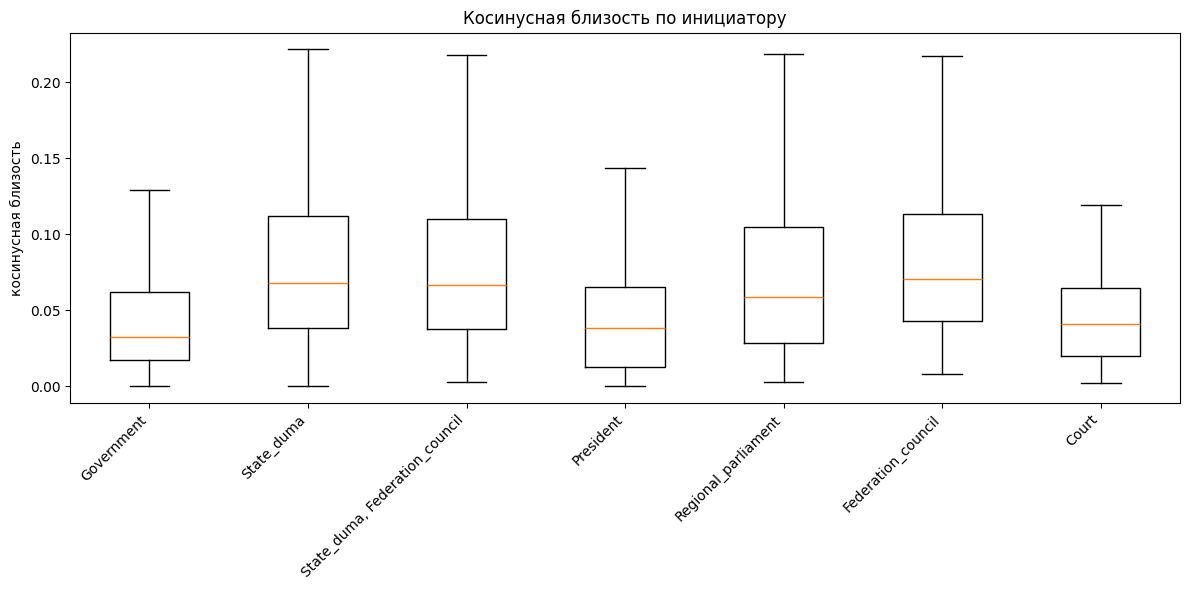

In [ ]:
print("\n=== Score by Initiator_type (combinations) ===")
print(grp.head(30))

big_groups = grp[grp['n'] >= min_n].index.tolist()

plot_df = df[df[type_col].isin(big_groups)].dropna(subset=[score_col, type_col])

top_k = 12
top_groups = grp.loc[big_groups].sort_values('n', ascending=False).head(top_k).index.tolist()

data_for_box = [plot_df.loc[plot_df[type_col] == g, score_col].values for g in top_groups]

plt.figure(figsize=(12, 6))
plt.boxplot(data_for_box, labels=top_groups, vert=True, showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.title(f"Косинусная близость по инициатору")
plt.ylabel("косинусная близость")
plt.tight_layout()
plt.show()

Проанализируем распределение законопроектов по профильным комитетам Государственной Думы и оценим численность каждой категории, чтобы выявить институциональную структуру парламентской специализации. Далее сопоставим основные описательные характеристики показателя score в разрезе комитетов, что позволит определить, связана ли степень переработки законопроектов с их тематической и процедурной юрисдикцией в рамках парламентской системы.

In [ ]:
committee_col = 'committee_group'

df = data.copy()

df[committee_col] = df[committee_col].astype(str).str.strip()

n_committees = df[committee_col].nunique()

print("Количество уникальных комитетов:", n_committees)

Количество уникальных комитетов: 13


In [ ]:
committee_counts = (
    df[committee_col]
      .value_counts()
      .reset_index()
      .rename(columns={'index': 'committee', committee_col: 'n_bills'})
)

print("\n=== Законопроекты по комитетам ===")
print(committee_counts.head(30))


=== Законопроекты по комитетам ===
        n_bills  count
0     LAW_STATE   1425
1       FINANCE   1030
2       ECONOMY    497
3       FOREIGN    422
4      SECURITY    395
5        SOCIAL    341
6         INFRA    312
7     EDUCATION    191
8   ENERGY_AGRO    137
9         OTHER    126
10       HEALTH    114
11      ECOLOGY     71
12     REGIONAL      8


In [ ]:
score_col = 'score'
min_n = 50

committee_stats = (
    df.dropna(subset=[score_col, committee_col])
      .groupby(committee_col)[score_col]
      .agg(n='count',
           mean='mean',
           median='median',
           std='std',
           p10=lambda s: s.quantile(0.10),
           p90=lambda s: s.quantile(0.90))
      .sort_values('n', ascending=False)
)

print("\n=== Score by committee ===")
print(committee_stats.head(20))


=== Score by committee ===
                    n      mean    median       std       p10       p90
committee_group                                                        
LAW_STATE        1369  0.064663  0.040176  0.073988  0.009542  0.149357
FINANCE           977  0.061105  0.037370  0.065557  0.007531  0.153150
ECONOMY           475  0.064843  0.047720  0.060652  0.013781  0.133101
FOREIGN           421  0.068079  0.054172  0.047759  0.024109  0.149754
SECURITY          375  0.050794  0.035431  0.047859  0.008708  0.114373
SOCIAL            320  0.058773  0.035959  0.055535  0.011748  0.141534
INFRA             293  0.079320  0.056796  0.066110  0.016523  0.175158
EDUCATION         176  0.059060  0.040132  0.055136  0.012322  0.130669
ENERGY_AGRO       130  0.064372  0.047273  0.052046  0.019423  0.141714
OTHER             123  0.069461  0.049367  0.060458  0.016001  0.136506
HEALTH            111  0.061584  0.046257  0.055360  0.013014  0.119043
ECOLOGY            67  0.094324  0.0

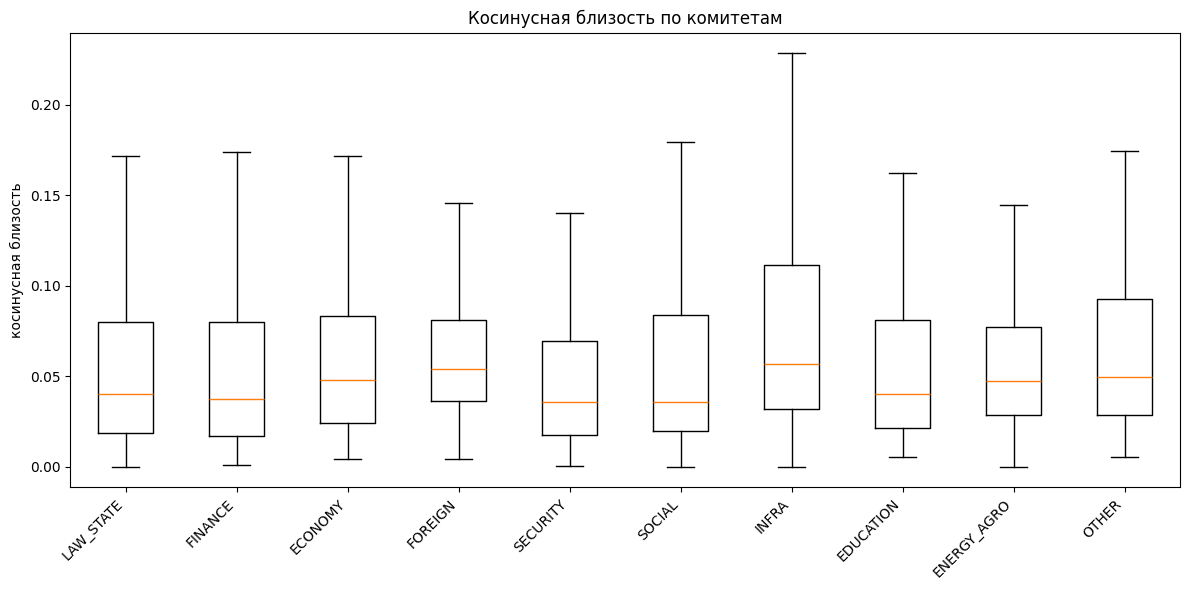

In [ ]:
big_committees = committee_stats[committee_stats['n'] >= min_n].index.tolist()

top_k = 10
top_committees = committee_stats.loc[big_committees].head(top_k).index.tolist()

plot_df = df[df[committee_col].isin(top_committees)].dropna(subset=[score_col])

data_for_box = [
    plot_df.loc[plot_df[committee_col] == c, score_col].values
    for c in top_committees
]

plt.figure(figsize=(12, 6))
plt.boxplot(data_for_box, tick_labels=top_committees, showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.title("Косинусная близость по комитетам")
plt.ylabel("косинусная близость")
plt.tight_layout()
plt.show()

Оценим связь между объёмом текста законопроекта и степенью его переработки. Для этого рассчитывается количество слов в исходной версии текста и определяется показатель глубины изменений (depth = 1 – cosine similarity). Далее будем вычислять коэффициенты корреляции Пирсона и Спирмена, позволяющие выявить линейную и монотонную зависимость между длиной текста и построим диаграмму рассеяния для визуального анализа распределения наблюдений.

Pearson correlation: PearsonRResult(statistic=np.float64(0.15171913453929564), pvalue=np.float64(2.4219052052771378e-26))
Spearman correlation: SignificanceResult(statistic=np.float64(0.3545201090278521), pvalue=np.float64(1.8137658509146402e-143))


/tmp/ipython-input-827/2678966329.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["text_length_words"] = (
/tmp/ipython-input-827/2678966329.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["depth"] = 1 - data["score"]


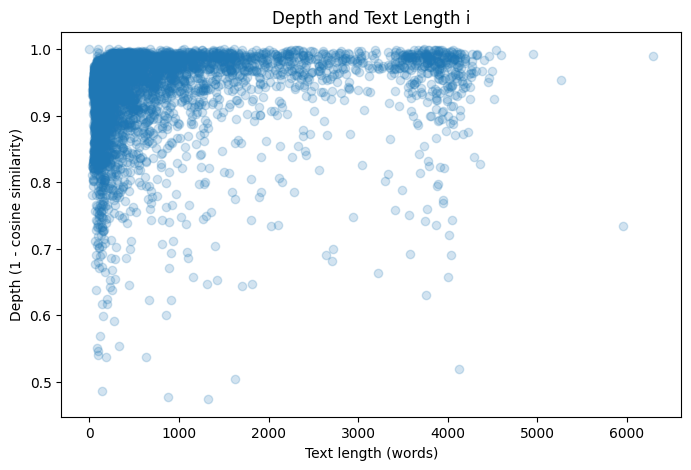

In [ ]:
data["depth"] = 1 - data["score"]

pearson_corr = pearsonr(data["text_length_words"], data["depth"])
spearman_corr = spearmanr(data["text_length_words"], data["depth"])

print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)


plt.figure(figsize=(8,5))
plt.scatter(data["text_length_words"], data["depth"], alpha=0.2)
plt.xlabel("Text length (words)")
plt.ylabel("Depth (1 - cosine similarity)")
plt.title("Depth and Text Length i")
plt.show()

Проверим, не образуют ли наиболее объемные законопроекты отдельную группу с особыми характеристиками переработки, способную повлиять на общую зависимость между длиной текста и глубиной изменений.

In [ ]:
data["text_length_words"].describe(percentiles=[.75, .9, .95, .99])

,text_length_words
count,4845.000000
mean,810.116615
std,1069.543662
min,1.000000
50%,329.000000
75%,947.000000
90%,2470.600000
95%,3719.800000
99%,4134.240000
max,6292.000000


In [ ]:
long_texts = data[data["text_length_words"] > 3500]

print("Количество длинных текстов:", len(long_texts))

Количество длинных текстов: 322


In [ ]:
long_texts["Initiator_type"].value_counts()

,count
Initiator_type,
Government,202
State_duma,50
"State_duma, Federation_council",37
President,26
Court,5
Federation_council,2


In [ ]:
long_texts["committee_group"].value_counts()

,count
committee_group,
FINANCE,104
ECONOMY,59
LAW_STATE,53
INFRA,31
SOCIAL,20
SECURITY,19
EDUCATION,14
ENERGY_AGRO,6
FOREIGN,5


Посмотрим на динамику глубины переработки законопроектов во времени. Для этого сгруппируем наблюдения по годам внесения инициативы, рассчитаем среднее и медианное значение показателя глубины (1 – cosine similarity) для каждого года и визуализируем полученные значения. Это позволит оценить, присутствует ли временной тренд в степени изменений текста законопроектов.

    year      mean    median  count
0   2011  0.964701  0.978068      4
1   2012  0.929030  0.951933    393
2   2013  0.934314  0.956146    459
3   2014  0.934414  0.956065    538
4   2015  0.931883  0.952539    450
5   2016  0.942983  0.960654    442
6   2017  0.933114  0.951568    536
7   2018  0.934792  0.954940    577
8   2019  0.939678  0.959416    522
9   2020  0.938642  0.963621    555
10  2021  0.942408  0.963962    369


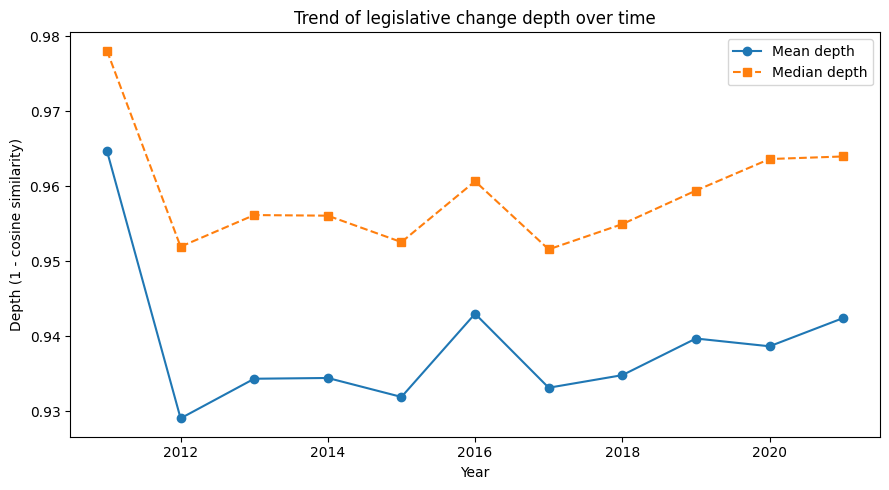

In [ ]:
yearly = (
    data
    .groupby("year")["depth"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

print(yearly)

plt.figure(figsize=(9,5))

plt.plot(yearly["year"], yearly["mean"], marker="o", label="Mean depth")
plt.plot(yearly["year"], yearly["median"], marker="s", linestyle="--", label="Median depth")

plt.xlabel("Year")
plt.ylabel("Depth (1 - cosine similarity)")
plt.title("Trend of legislative change depth over time")
plt.legend()
plt.tight_layout()
plt.show()

###**Построение моделей**

In [170]:
df = data.copy()
df = df.dropna(subset=["depth"])
df = df[df["depth"].between(0, 1, inclusive="both")]
n = len(df)
df["depth_sq"] = (df["depth"] * (n - 1) + 0.5) / n
df["log_text_len"] = np.log1p(df["text_length_words"])

print(f"Наблюдений после очистки: {n}")
print(f"depth_sq: min={df['depth_sq'].min():.4f}, max={df['depth_sq'].max():.4f}")

ACTORS = [c for c in [
    "actor_government", "actor_president",
    "actor_federation_council", "actor_court",
    "actor_regional_parliament",
] if c in df.columns]

COMMITTEES = [c for c in [
    "committee_finance", "committee_economy", "committee_law_state",
    "committee_security", "committee_social", "committee_health",
    "committee_education", "committee_infra", "committee_ecology",
    "committee_energy_agro", "committee_foreign", "committee_regional",
] if c in df.columns]

CONTROLS = ["log_text_len", "year"]

LABEL_MAP_RU = {
    "actor_government":              "Правительство",
    "actor_president":               "Президент",
    "actor_federation_council":      "Совет Федерации",
    "actor_court":                   "Суды",
    "actor_regional_parliament":     "Региональные парламенты",
    "committee_finance":             "Финансы",
    "committee_economy":             "Экономика",
    "committee_law_state":           "Госстроительство и право",
    "committee_security":            "Безопасность",
    "committee_social":              "Социальная политика",
    "committee_health":              "Здравоохранение",
    "committee_education":           "Образование и наука",
    "committee_infra":               "Инфраструктура и ЖКХ",
    "committee_ecology":             "Экология",
    "committee_energy_agro":         "Энергетика и АПК",
    "committee_foreign":             "Международные дела",
    "committee_regional":            "Региональная политика",
    "log_text_len":                  "Длина текста (log)",
    "year":                          "Год внесения",
    "actor_government:committee_finance":          "Правительство × Финансы",
    "actor_government:committee_economy":          "Правительство × Экономика",
    "actor_government:committee_social":           "Правительство × Социальная политика",
    "actor_government:committee_security":         "Правительство × Безопасность",
    "actor_president:committee_foreign":           "Президент × Международные дела",
    "actor_president:committee_security":          "Президент × Безопасность",
    "actor_president:committee_law_state":         "Президент × Госстроительство",
    "actor_federation_council:committee_regional": "СФ × Региональная политика",
}

Наблюдений после очистки: 4845
depth_sq: min=0.4738, max=0.9999


In [171]:

try:
    from statsmodels.othermod.betareg import BetaModel
    BETA_AVAILABLE = True
    print("BetaModel доступен — используем настоящую beta-регрессию\n")
except ImportError:
    BETA_AVAILABLE = False
    print("BetaModel недоступен — используем GLM Binomial (логит-линк)\n")


def fit_model(formula, data, label=""):
    if BETA_AVAILABLE:
        result = BetaModel.from_formula(formula, data=data).fit(disp=False)
    else:
        result = smf.glm(
            formula, data=data,
            family=sm.families.Binomial(link=sm.families.links.Logit())
        ).fit()
    print(f"\n{'='*60}\n  {label}\n{'='*60}")
    print(result.summary())
    return result


def get_coef_df(result):
    params  = result.params
    bse     = result.bse
    pvalues = result.pvalues
    conf    = result.conf_int()
    return pd.DataFrame({
        "coef":    params,
        "se":      bse,
        "pvalue":  pvalues,
        "ci_low":  conf.iloc[:, 0],
        "ci_high": conf.iloc[:, 1],
    })


BetaModel доступен — используем настоящую beta-регрессию



In [172]:
f1 = "depth_sq ~ " + " + ".join(ACTORS + CONTROLS)
m1 = fit_model(f1, df, "Модель 1 — Инициатор закнопроекта")


  Модель 1 — Инициатор закнопроекта
                              BetaModel Results                               
Dep. Variable:               depth_sq   Log-Likelihood:                 8973.7
Model:                      BetaModel   AIC:                        -1.793e+04
Method:            Maximum Likelihood   BIC:                        -1.787e+04
Date:                Sun, 01 Mar 2026                                         
Time:                        09:56:09                                         
No. Observations:                4845                                         
Df Residuals:                    4836                                         
Df Model:                           7                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                   -13.3879      7.722     -1.734      

In [173]:
f2 = "depth_sq ~ " + " + ".join(COMMITTEES + CONTROLS)
m2 = fit_model(f2, df, "Модель 2 — Тематика законопроекта")


  Модель 2 — Тематика законопроекта
                              BetaModel Results                               
Dep. Variable:               depth_sq   Log-Likelihood:                 8787.8
Model:                      BetaModel   AIC:                        -1.754e+04
Method:            Maximum Likelihood   BIC:                        -1.744e+04
Date:                Sun, 01 Mar 2026                                         
Time:                        09:56:27                                         
No. Observations:                4845                                         
Df Residuals:                    4829                                         
Df Model:                          14                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -20.2921      8.041     -2.523      0.012     -3

In [174]:
INTERACTIONS = [
    "actor_president:committee_foreign",
    "actor_president:committee_security",
    "actor_president:committee_law_state",
    "actor_government:committee_finance",
    "actor_government:committee_social",
    "actor_government:committee_security",
    "actor_federation_council:committee_regional",
]
valid_interactions = [
    ix for ix in INTERACTIONS
    if all(v in df.columns for v in ix.split(":"))
]

f3 = ("depth_sq ~ " +
      " + ".join(ACTORS) +
      " + " + " + ".join(COMMITTEES) +
      ((" + " + " + ".join(valid_interactions)) if valid_interactions else "") +
      " + log_text_len + year")
m3 = fit_model(f3, df, "Модель 3 — Инициатор × Тематика (взаимодействия)")


  Модель 3 — Инициатор × Тематика (взаимодействия)
                              BetaModel Results                               
Dep. Variable:               depth_sq   Log-Likelihood:                 9031.3
Model:                      BetaModel   AIC:                        -1.801e+04
Method:            Maximum Likelihood   BIC:                        -1.783e+04
Date:                Sun, 01 Mar 2026                                         
Time:                        09:57:04                                         
No. Observations:                4845                                         
Df Residuals:                    4817                                         
Df Model:                          26                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept    

In [175]:
def extract_coefs(result, model_name):
    tbl = get_coef_df(result).copy()
    tbl = tbl.apply(pd.to_numeric, errors="coerce")
    tbl["model"] = model_name
    tbl.index.name = "variable"
    return tbl.reset_index()

try:
    comp = pd.concat([
        extract_coefs(m1, "M1_Actor"),
        extract_coefs(m2, "M2_Committee"),
        extract_coefs(m3, "M3_Interaction"),
    ], ignore_index=True)
    pivot = comp.pivot_table(
        index="variable", columns="model", values="coef", aggfunc="first"
    ).round(4)
    print("\n\n" + "="*60)
    print("  СРАВНИТЕЛЬНАЯ ТАБЛИЦА (коэффициенты)")
    print("="*60)
    print(pivot.to_string())
except Exception as e:
    print(f"Сравнительная таблица не построена: {e}")



  СРАВНИТЕЛЬНАЯ ТАБЛИЦА (коэффициенты)
model                                        M1_Actor  M2_Committee  M3_Interaction
variable                                                                           
Intercept                                    -13.3879      -20.2921        -19.4614
actor_court                                    0.3800           NaN          0.2928
actor_federation_council                      -0.0772           NaN         -0.0738
actor_federation_council:committee_regional       NaN           NaN          0.3099
actor_government                               0.4681           NaN          0.4156
actor_government:committee_finance                NaN           NaN          0.1559
actor_government:committee_security               NaN           NaN          0.1829
actor_government:committee_social                 NaN           NaN          0.2293
actor_president                                0.5957           NaN          0.8942
actor_president:committee_foreign  

In [176]:
def plot_coefs(result, title, vars_to_plot=None, xlabel="Оценка коэффициента (логит-шкала)"):
    tbl = get_coef_df(result).copy()
    tbl = tbl.apply(pd.to_numeric, errors="coerce")

    tbl = tbl[~tbl.index.isin(["Intercept", "precision"])]

    if vars_to_plot:
        tbl = tbl[tbl.index.isin(vars_to_plot)]

    tbl = tbl.dropna(subset=["coef"]).sort_values("coef")

    if tbl.empty:
        print(f"Нет данных для графика: {title}")
        return

    labels = [LABEL_MAP_RU.get(v, v.replace("_", " ")) for v in tbl.index]
    significant = tbl["pvalue"] < 0.05

    plt.figure(figsize=(10, max(5, len(tbl) * 0.55)))

    for i, (idx, row) in enumerate(tbl.iterrows()):
        color = "firebrick" if significant.loc[idx] else "gray"
        plt.errorbar(
            x=row["coef"],
            y=i,
            xerr=1.96 * row["se"],
            fmt="o",
            color=color,
            ecolor=color,
            capsize=4,
            markersize=6,
            linewidth=1.4,
            label="_nolegend_"
        )

    plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
    plt.yticks(range(len(labels)), labels, fontsize=10)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Переменная", fontsize=12)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.grid(axis="x", linestyle=":", linewidth=0.7)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="firebrick",
               markersize=8, label="p < 0.05"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
               markersize=8, label="p ≥ 0.05"),
    ]
    plt.legend(handles=legend_elements, fontsize=10, loc="lower right")
    plt.tight_layout()
    plt.show()

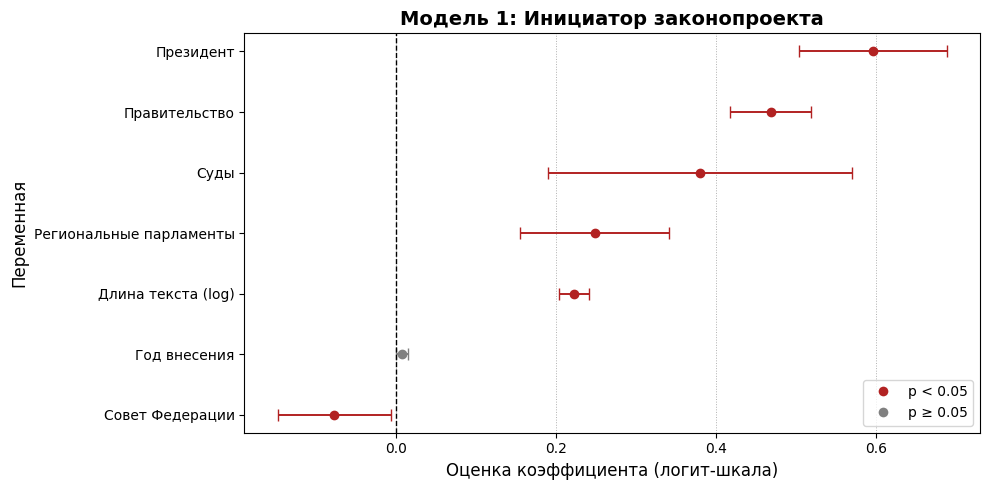

In [179]:
plot_coefs(m1,
           "Модель 1: Инициатор законопроекта",
           vars_to_plot=ACTORS + CONTROLS)

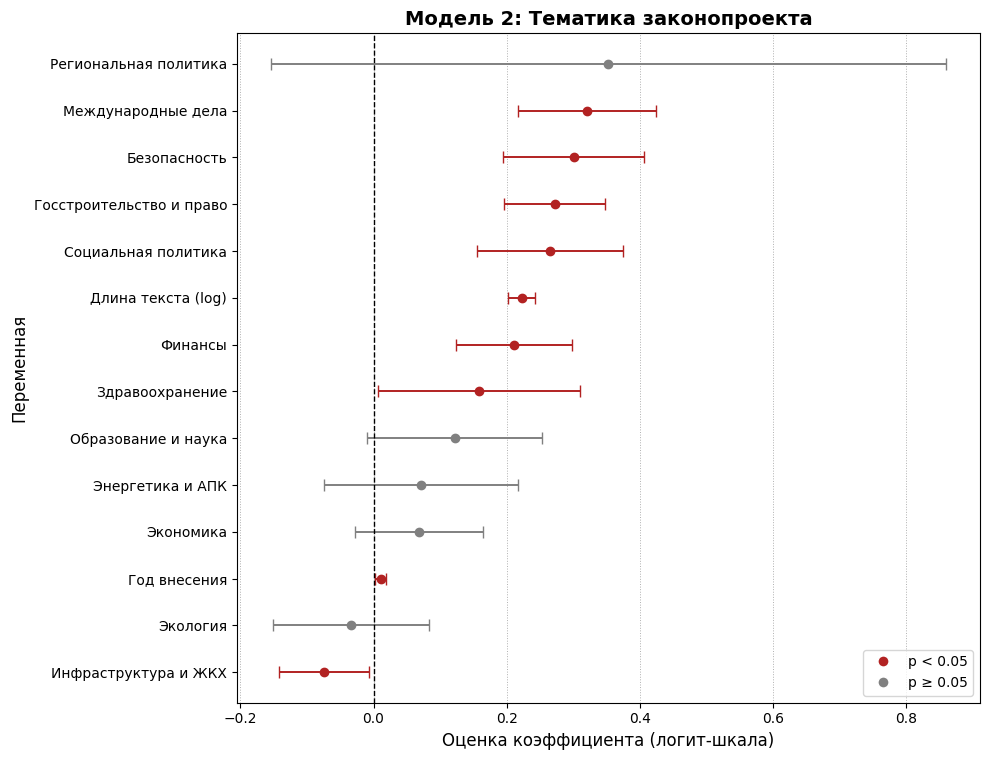

In [180]:
plot_coefs(m2,
           "Модель 2: Тематика законопроекта",
           vars_to_plot=COMMITTEES + CONTROLS)

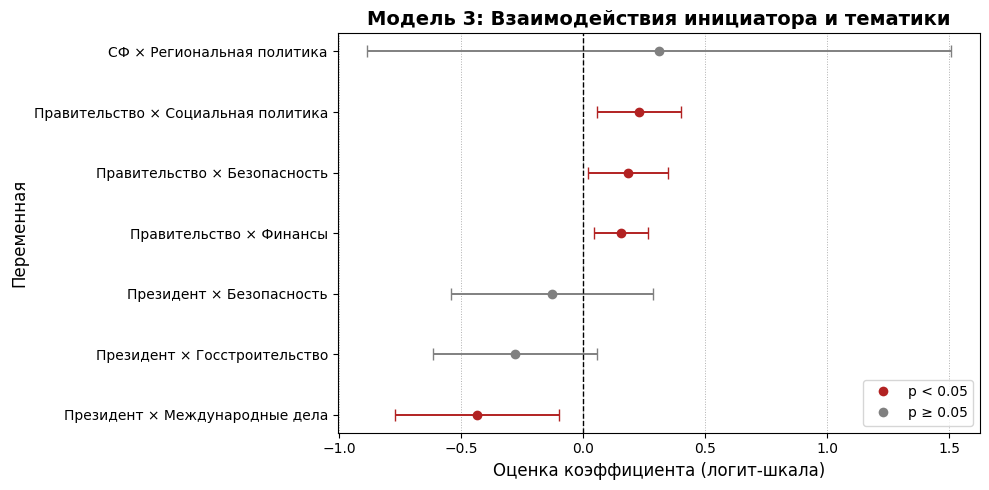

In [184]:
if valid_interactions:
    plot_coefs(m3,
               "Модель 3: Взаимодействия инициатора и тематики",
               vars_to_plot=valid_interactions)

In [182]:
print("\n\n" + "="*60)
print("  КАЧЕСТВО МОДЕЛЕЙ")
print("="*60)
for name, m in [("M1", m1), ("M2", m2), ("M3", m3)]:
    try:
        print(f"{name}:  AIC={m.aic:.2f}  BIC={m.bic:.2f}  LogLik={m.llf:.2f}")
    except Exception as e:
        print(f"{name}: {e}")



  КАЧЕСТВО МОДЕЛЕЙ
M1:  AIC=-17929.44  BIC=-17871.07  LogLik=8973.72
M2:  AIC=-17543.64  BIC=-17439.86  LogLik=8787.82
M3:  AIC=-18006.65  BIC=-17825.05  LogLik=9031.32
